In [3]:
import pandas as pd

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

In [4]:
df = df[
    (df['Mixture'] == 'Chemical') &
    (df['Species'] == 'Human') &
    (df['Endpoint'] == 'Qualitative classification')
].copy()

In [5]:
df['label'] = (
    df['Response'].str.strip() != 'Not classified'
).astype(int)

In [6]:
df = df.dropna(subset=['SMILES']).copy()

In [7]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

In [8]:
desc_list = []

for smi in df['SMILES']:
    
    mol = Chem.MolFromSmiles(smi)
    
    if mol is not None:
        
        desc = Descriptors.CalcMolDescriptors(mol)
        
        desc_list.append(desc)

[15:46:13] Explicit valence for atom # 2 B, 5, is greater than permitted


In [9]:
X = pd.DataFrame(desc_list)

In [10]:
y = df['label'].reset_index(drop=True)

In [11]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.dropna(axis=1)

X = X.loc[:, X.std() >= 0.01]

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

In [14]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np

desc_list = []
valid_rows = []

for idx, row in df.iterrows():
    smi = row['SMILES']
    mol = Chem.MolFromSmiles(smi)
    
    if mol is not None:
        desc = Descriptors.CalcMolDescriptors(mol)
        desc_list.append(desc)
        valid_rows.append(idx)

X = pd.DataFrame(desc_list)

df = df.loc[valid_rows].reset_index(drop=True)
y = df['label'].reset_index(drop=True)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1)
X = X.loc[:, X.std() >= 0.01]

print(X.shape)
print(y.shape)
print(df.shape)

(69, 148)
(69,)
(69, 26)


[15:47:25] Explicit valence for atom # 2 B, 5, is greater than permitted


In [15]:
plot_df = X.copy()

plot_df['label'] = y.values
plot_df['Chemical_Name'] = df['Chemical_Name'].values

In [16]:
X_scaled = StandardScaler().fit_transform(X)

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [18]:
plot_df['PC1'] = X_pca[:, 0]
plot_df['PC2'] = X_pca[:, 1]

In [19]:
plot_df['LogP_group'] = pd.cut(
    plot_df['MolLogP'],
    bins=[-10, 0, 3, 10],
    labels=['Hydrophilic', 'Balanced', 'Hydrophobic']
)

In [20]:
xy = np.vstack([plot_df['PC1'], plot_df['PC2']])

z = gaussian_kde(xy)(xy)

In [21]:
plt.figure(figsize=(11, 8))

<Figure size 1100x800 with 0 Axes>

<Figure size 1100x800 with 0 Axes>

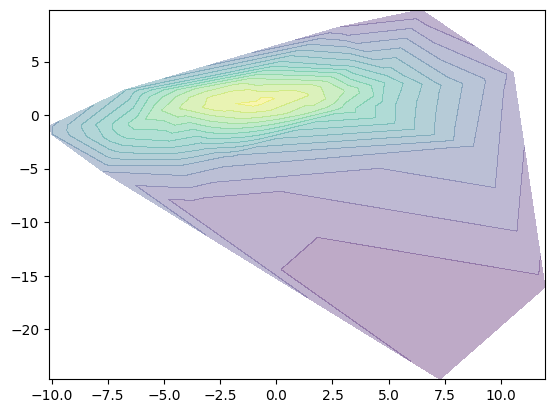

In [22]:
plt.tricontourf(
    plot_df['PC1'],
    plot_df['PC2'],
    z,
    levels=15,
    alpha=0.35
)
# 배경 밀도 등고선 그리기...
# 점들이 많이 몰린 곳을 배경 색으로 보여주는 코드임
# 진한 부분은 화합물이 많이 몰린 영역이고, 연한 부분은 적은 영역이라고 할 수 있음. 


In [23]:
markers = {
    'Hydrophilic': 'o',
    'Balanced': 's',
    'Hydrophobic': '^'
}

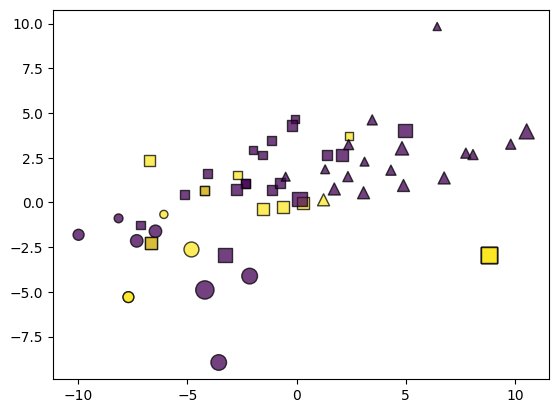

In [24]:
for group, marker in markers.items():
    sub = plot_df[plot_df['LogP_group'] == group]
    
    scatter = plt.scatter(
        sub['PC1'],
        sub['PC2'],
        c=sub['label'],
        s=sub['TPSA'] * 2,
        marker=marker,
        alpha=0.75,
        edgecolor='black',
        label=group
    )

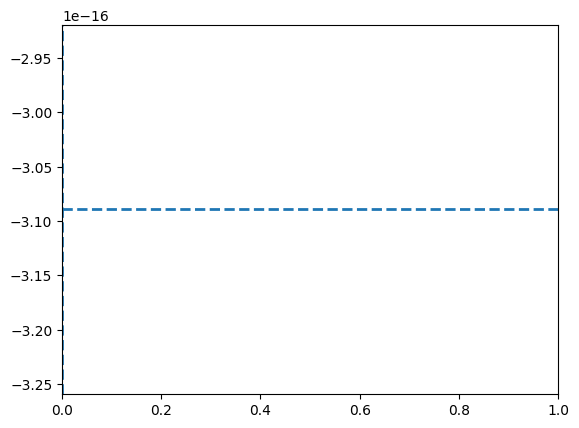

In [25]:
plt.axvline(
    plot_df['PC1'].mean(),
    linestyle='--',
    linewidth=2
)

plt.axhline(
    plot_df['PC2'].mean(),
    linestyle='--',
    linewidth=2
)

Text(9.819360673235865, -1.9183671110636542, 'Sodium dodecyl ')

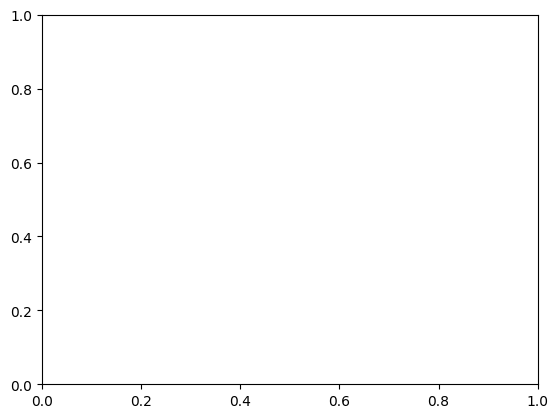

In [34]:
plt.annotate(
    row['Chemical_Name'][:15],
    
    xy=(row['PC1'], row['PC2']),
    
    xytext=(
        row['PC1'] + 1,
        row['PC2'] + 1
    ),
    
    arrowprops=dict(
        arrowstyle='->'
    ),
    
    fontsize=10
)

Text(0.5, 1.0, 'PCA-based Complex Chemical Space Plot')

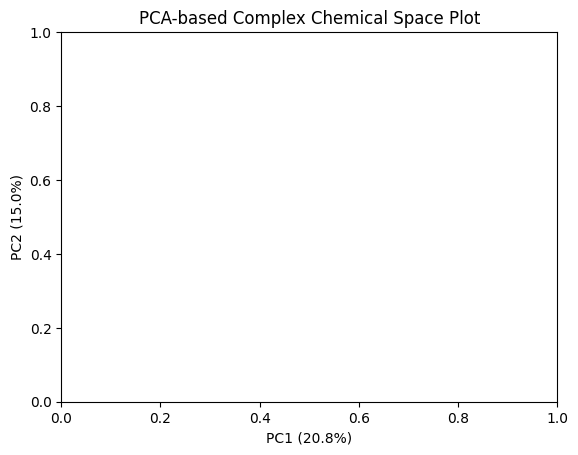

In [27]:
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.title('PCA-based Complex Chemical Space Plot')

In [28]:
cbar = plt.colorbar(scatter)

cbar.set_label('Skin irritation label')

cbar.set_ticks([0, 1])

cbar.set_ticklabels(['Not classified', 'Toxic'])

C:\Users\DS\AppData\Local\Temp\ipykernel_25436\2562696982.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter)


<Figure size 640x480 with 0 Axes>

C:\Users\DS\AppData\Local\Temp\ipykernel_25436\127334443.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='MolLogP group')


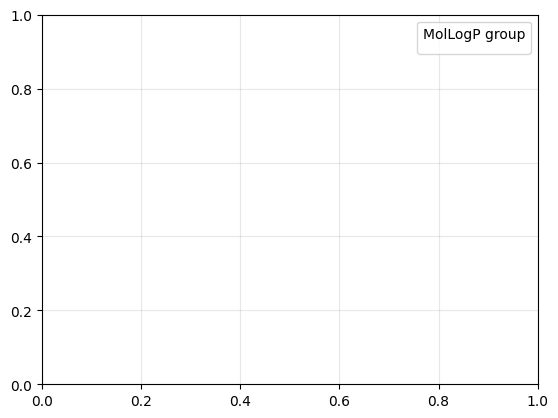

In [29]:
plt.legend(title='MolLogP group')
plt.grid(alpha=0.3)

plt.show()

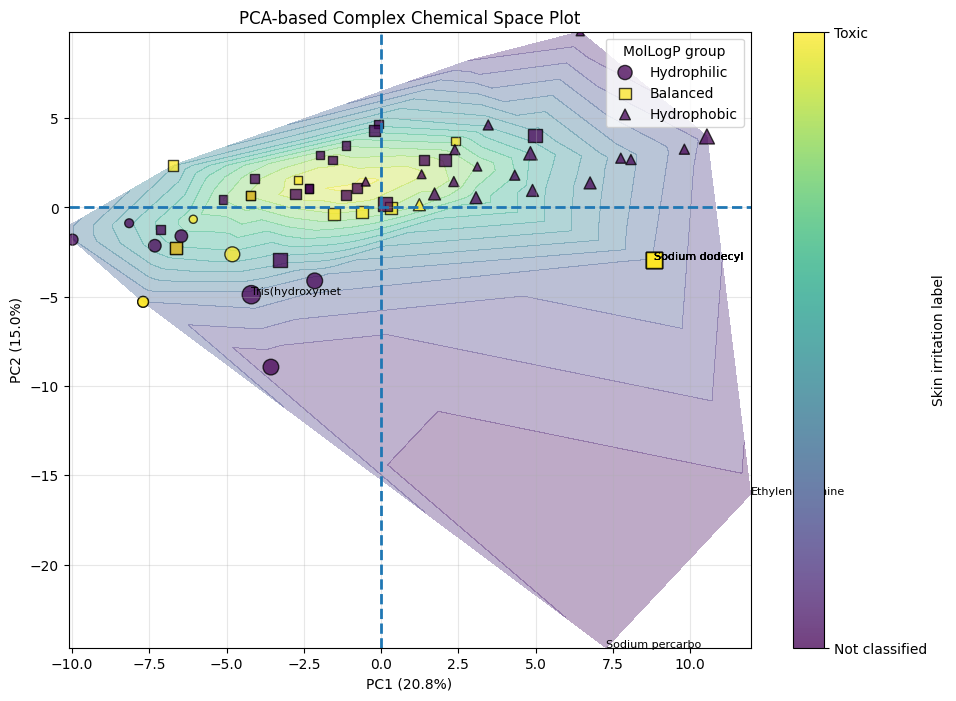

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

plot_df = X.copy()
plot_df['label'] = y.values
plot_df['Chemical_Name'] = df['Chemical_Name'].values

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df['PC1'] = X_pca[:, 0]
plot_df['PC2'] = X_pca[:, 1]

plot_df['LogP_group'] = pd.cut(
    plot_df['MolLogP'],
    bins=[-10, 0, 3, 10],
    labels=['Hydrophilic', 'Balanced', 'Hydrophobic']
)

xy = np.vstack([plot_df['PC1'], plot_df['PC2']])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(11, 8))

plt.tricontourf(
    plot_df['PC1'],
    plot_df['PC2'],
    z,
    levels=15,
    alpha=0.35
)

markers = {
    'Hydrophilic': 'o',
    'Balanced': 's',
    'Hydrophobic': '^'
}

for group, marker in markers.items():
    sub = plot_df[plot_df['LogP_group'] == group]
    
    scatter = plt.scatter(
        sub['PC1'],
        sub['PC2'],
        c=sub['label'],
        s=sub['TPSA'] * 2,
        marker=marker,
        alpha=0.75,
        edgecolor='black',
        label=group
    )

plt.axvline(
    plot_df['PC1'].mean(),
    linestyle='--',
    linewidth=2
)

plt.axhline(
    plot_df['PC2'].mean(),
    linestyle='--',
    linewidth=2
)

top_tpsa = plot_df.sort_values('TPSA', ascending=False).head(8)

for i, row in top_tpsa.iterrows():
    plt.text(
        row['PC1'],
        row['PC2'],
        row['Chemical_Name'][:15],
        fontsize=8
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA-based Complex Chemical Space Plot')

cbar = plt.colorbar(scatter)
cbar.set_label('Skin irritation label')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Not classified', 'Toxic'])

plt.legend(title='MolLogP group')
plt.grid(alpha=0.3)
plt.show()